In [1]:
import torch
from torch import nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

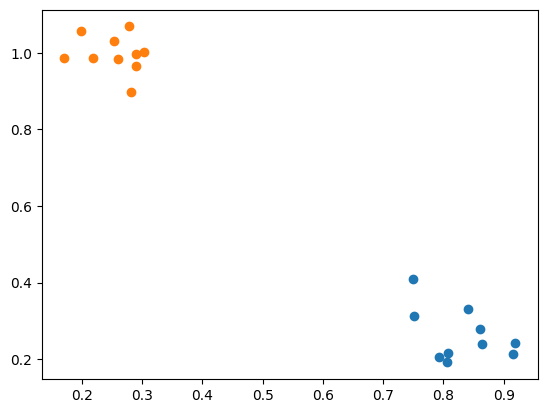

In [2]:
data2 = .05* np.random.randn(10, 2) + np.array([.25, 1]).reshape(1, 2)
data1 = .05* np.random.randn(10, 2) + np.array([.85, .25]).reshape(1, 2)

plt.scatter(data1[:, 0], data1[:, 1])
plt.scatter(data2[:, 0], data2[:, 1])

In [3]:

class Bcos(nn.Module):
    def __init__(self, inp=2, out=20, B=1):
        super().__init__()
        self.w = nn.Parameter(torch.empty((inp, out)))

        nn.init.xavier_normal_(self.w)
        self.B = B

    def forward(self, x):
        # x: (batch_size, dim)
        output1 = (x/x.norm(p=2, dim=1, keepdim=True)) @ self.w
        # print(((output1.abs()**self.B) * output1.sign()).shape)
        return (output1.abs()**self.B) * output1.sign() * x.norm(p=2, dim=1, keepdim=True)

class BcosAffine(nn.Module):
    def __init__(self, inp=2, out=20, B=1):
        super().__init__()
        self.w = nn.Parameter(torch.empty((inp, out)))
        self.b = nn.Parameter(torch.empty((1, out)))

        nn.init.xavier_normal_(self.w)
        nn.init.xavier_normal_(self.b)
        self.B = B

    def forward(self, x):
        # x: (batch_size, dim)
        output1 = (x/x.norm(p=2, dim=1, keepdim=True)) @ self.w
        # print(((output1.abs()**self.B) * output1.sign()).shape)
        return (output1.abs()**self.B) * output1.sign() * x.norm(p=2, dim=1, keepdim=True) + (self.b/self.b.norm(p=2, dim=1, keepdim=True))


class RBF(nn.Module):
    def __init__(self, inp=2, out=20, B=1):
        super().__init__()
        self.w = nn.Parameter(torch.empty((inp, out)))
        self.gamma = nn.Parameter(torch.empty((1, 1)))

        nn.init.xavier_normal_(self.w)
        nn.init.xavier_normal_(self.gamma)
        self.B = B

    def forward(self, x):
        # x: (batch_size, dim)
        x_norm = (x/x.norm(p=2, dim=1, keepdim=True))
        output1 = torch.exp(self.gamma * torch.norm(x_norm[..., None] - self.w, p=B, dim=1)**B)
        return output1.abs() * output1.sign() * (x.norm(p=2, dim=1, keepdim=True))

        # return x * (output1.abs()**self.B) #.norm(p=2, dim=1, keepdim=True)


B = 2
# bcos = nn.Sequential(*[Bcos(2, 20, B=B), Bcos(20, 1, B=B)])
bcos = nn.Sequential(*[BcosAffine(2, 20, B=B), BcosAffine(20, 1, B=B)])
# bcos = nn.Sequential(*[RBF(2, 20, B=B), RBF(20, 1, B=B)])
x = torch.randn(32, 2)
bcos(x).shape

torch.Size([32, 1])

## B-cos (standard)

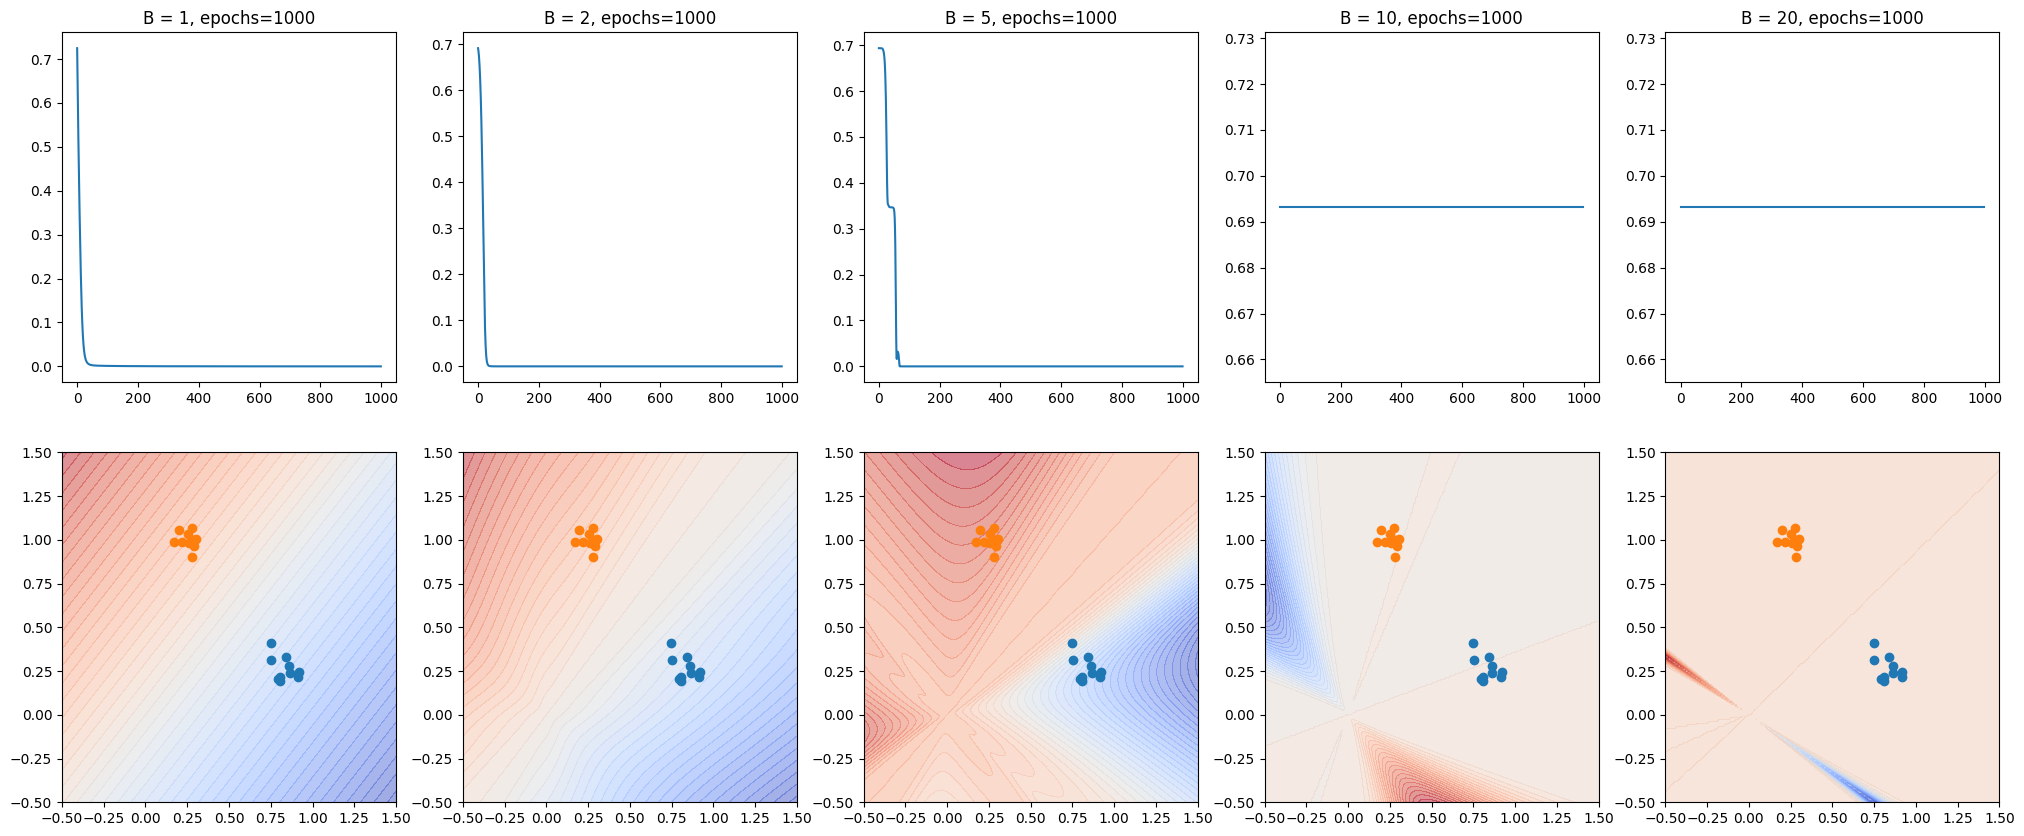

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(5*5, 2*5))

loss_fn = nn.BCEWithLogitsLoss()
epochs = 1000

_data2 = torch.from_numpy(data2).to(torch.float)
_data1 = torch.from_numpy(data1).to(torch.float)

X = torch.vstack([_data1, _data2])
y = torch.vstack([torch.zeros((10, 1)), torch.ones((10, 1))])

Bs = [1, 2, 5, 10, 20]

r = np.linspace(-0.5, 1.5, 200)
xx, yy = np.meshgrid(r, r)
D = np.vstack([xx.ravel(), yy.ravel()]).T

_D = torch.from_numpy(D).to(torch.float)

for B, ax_col in zip(Bs, axes.T):

    losses = []

    bcos = nn.Sequential(*[Bcos(2, 100, B=B), Bcos(100, 1, B=B)])

    optim = torch.optim.AdamW(bcos.parameters(), lr=0.01)

    for i in range(epochs):

        y_hat = bcos(X)

        loss = loss_fn(y_hat, y)

        optim.zero_grad()

        loss.backward()

        optim.step()

        losses.append(loss.item())
    
    ax_col[0].plot(losses)
    ax_col[0].set_title(f"B = {B}, epochs={epochs}")
    ax_col[1].contourf(xx, yy, bcos(_D).detach().numpy().reshape(xx.shape), alpha=0.5, levels=50, cmap='coolwarm')
    ax_col[1].scatter(data1[:, 0], data1[:, 1])
    ax_col[1].scatter(data2[:, 0], data2[:, 1])


## B-cos (affine version)

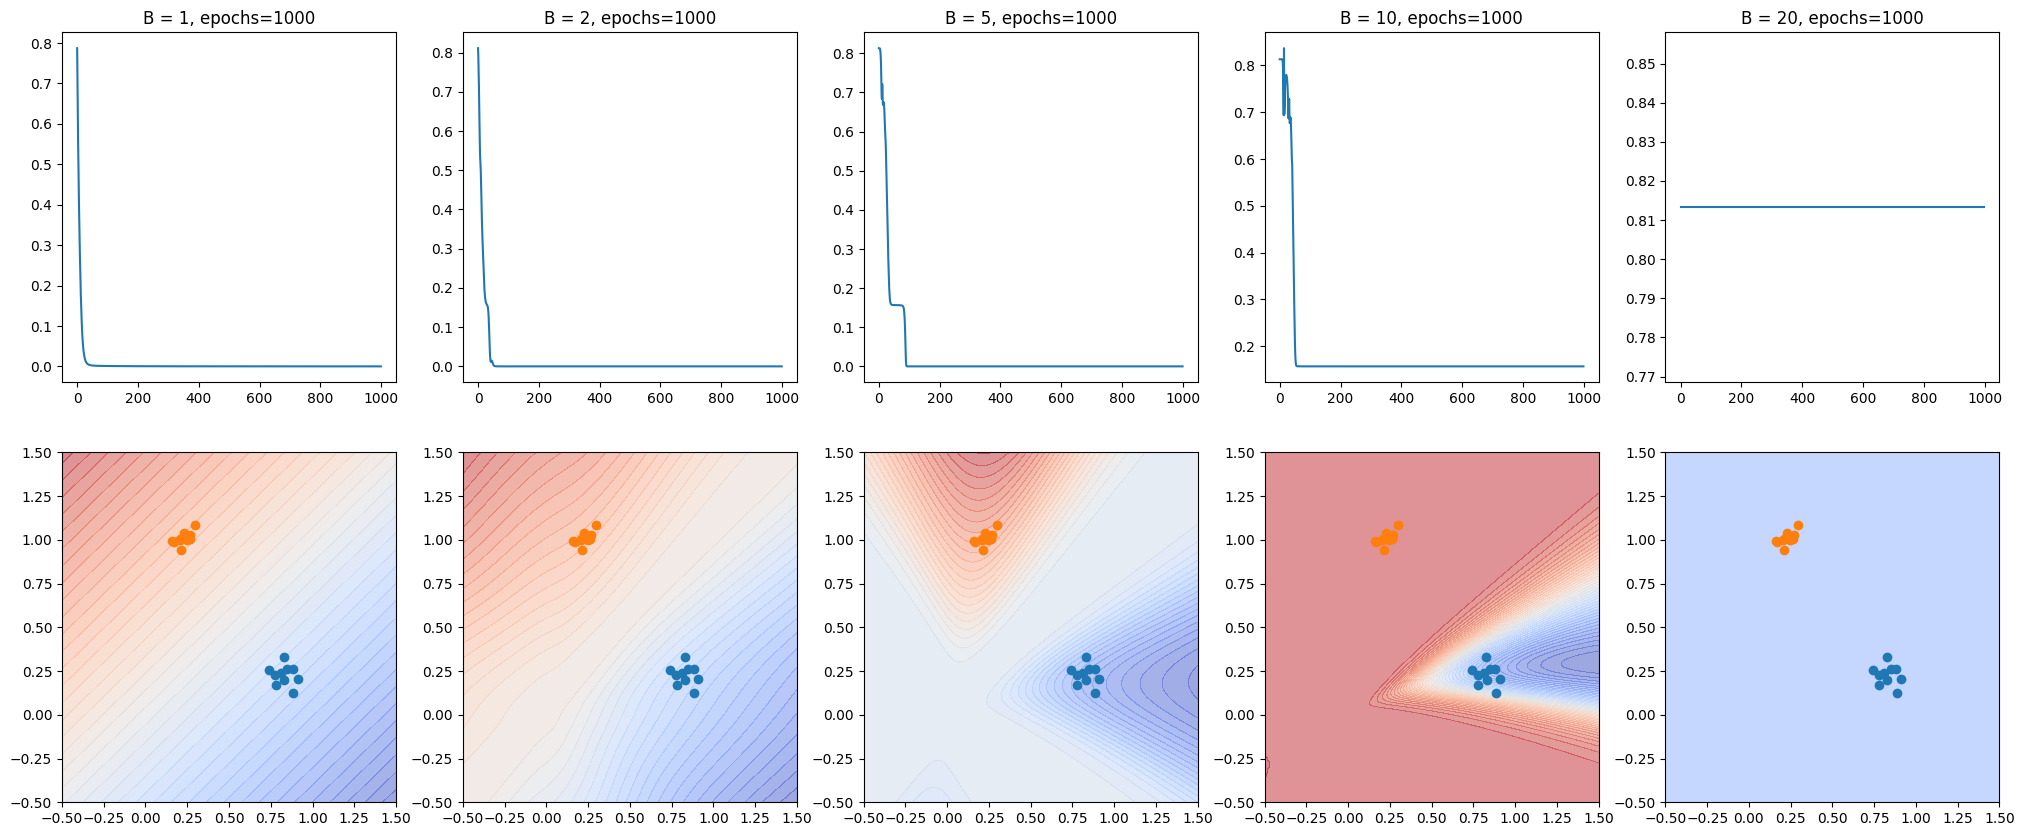

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(5*5, 2*5))

loss_fn = nn.BCEWithLogitsLoss()
epochs = 1000

_data2 = torch.from_numpy(data2).to(torch.float)
_data1 = torch.from_numpy(data1).to(torch.float)

X = torch.vstack([_data1, _data2])
y = torch.vstack([torch.zeros((10, 1)), torch.ones((10, 1))])

Bs = [1, 2, 5, 10, 20]

r = np.linspace(-0.5, 1.5, 200)
xx, yy = np.meshgrid(r, r)
D = np.vstack([xx.ravel(), yy.ravel()]).T

_D = torch.from_numpy(D).to(torch.float)

for B, ax_col in zip(Bs, axes.T):

    losses = []

    bcos = nn.Sequential(*[BcosAffine(2, 100, B=B), BcosAffine(100, 1, B=B)])

    optim = torch.optim.AdamW(bcos.parameters(), lr=0.01)

    for i in range(epochs):

        y_hat = bcos(X)

        loss = loss_fn(y_hat, y)

        optim.zero_grad()

        loss.backward()

        optim.step()

        losses.append(loss.item())
    
    ax_col[0].plot(losses)
    ax_col[0].set_title(f"B = {B}, epochs={epochs}")
    ax_col[1].contourf(xx, yy, bcos(_D).detach().numpy().reshape(xx.shape), alpha=0.5, levels=50, cmap='coolwarm')
    ax_col[1].scatter(data1[:, 0], data1[:, 1])
    ax_col[1].scatter(data2[:, 0], data2[:, 1])


## B-cos (RBF version)

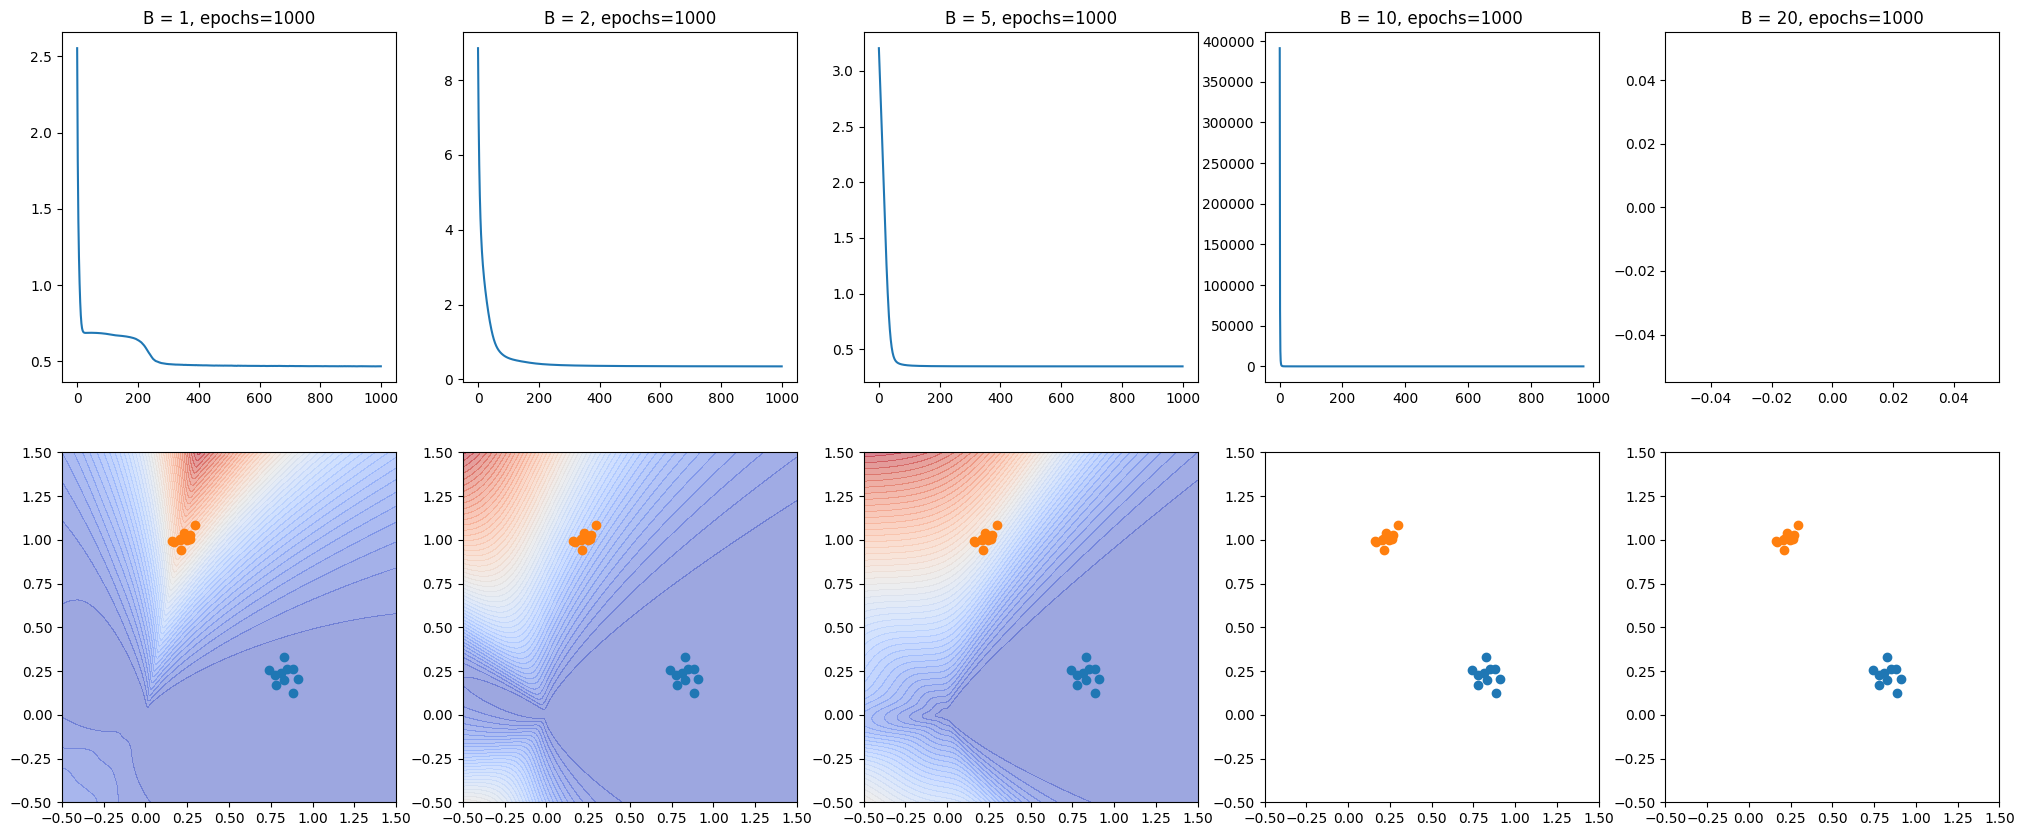

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(5*5, 2*5))

loss_fn = nn.BCEWithLogitsLoss()
epochs = 1000

_data2 = torch.from_numpy(data2).to(torch.float)
_data1 = torch.from_numpy(data1).to(torch.float)

X = torch.vstack([_data1, _data2])
y = torch.vstack([torch.zeros((10, 1)), torch.ones((10, 1))])

Bs = [1, 2, 5, 10, 20]

r = np.linspace(-0.5, 1.5, 200)
xx, yy = np.meshgrid(r, r)
D = np.vstack([xx.ravel(), yy.ravel()]).T

_D = torch.from_numpy(D).to(torch.float)

for B, ax_col in zip(Bs, axes.T):

    losses = []

    bcos = nn.Sequential(*[RBF(2, 100, B=B), RBF(100, 1, B=B)])

    optim = torch.optim.AdamW(bcos.parameters(), lr=0.01)

    for i in range(epochs):

        y_hat = bcos(X)

        loss = loss_fn(y_hat, y)

        optim.zero_grad()

        loss.backward()

        optim.step()

        losses.append(loss.item())
    
    ax_col[0].plot(losses)
    ax_col[0].set_title(f"B = {B}, epochs={epochs}")
    ax_col[1].contourf(xx, yy, bcos(_D).detach().numpy().reshape(xx.shape), alpha=0.5, levels=50, cmap='coolwarm')
    ax_col[1].scatter(data1[:, 0], data1[:, 1])
    ax_col[1].scatter(data2[:, 0], data2[:, 1])
